<a href="https://colab.research.google.com/github/Markwema86/Portfolio-Analysis-Engine/blob/main/Risk_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Module 3 - Risk Management**

 Tools that risk departments use:
- **TOOL 1**  Value at Risk (VaR)

"How much could we lose on a bad day?"                      
- **TOOL 2** - Stress Testing

"What if 2008 happens again?"                
- **TOOL 3** - Monte Carlo Simulation

"What are the 1,000 possible futures of this portfolio?"

**Tool 1 - Value at Risk (VaR)**

VaR answers one specific question:

- "At 95% confidence - what is the maximum amount this portfolio could lose in a single day?"

If VaR is -2.5%, it means: on 95% of days, you won't lose more than 2.5%. But on the worst 5% of days - you could lose more than that.

Every bank, hedge fund and asset manager calculates this daily. It's regulatory requirement in most countries.

#### Calculating VaR Three Ways

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats

# Our diversified portfolio
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'JNJ']
weights = np.array([0.20, 0.20, 0.15, 0.10, 0.05, 0.20, 0.10])

# Pulling 4 years of data
data = yf.download(tickers, start='2022-01-01', end='2026-01-01')['Close']
returns = data.pct_change().dropna()

# Portfolio daily returns
portfolio_returns = returns.dot(weights)

print(f"Total trading days: {len(portfolio_returns)}")
print(f"Average daily return: {portfolio_returns.mean():.4%}")
print(f"Daily volatility: {portfolio_returns.std():.4%}")

/tmp/ipykernel_2067/3790088972.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2022-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  7 of 7 completed

Total trading days: 1002
Average daily return: 0.0658%
Daily volatility: 1.5464%


#### Method 1: Historical VaR

simplest and most honest method

In [28]:
# Historical VaR at 95% confidence
confidence = 0.95
var_95_historical = np.percentile(portfolio_returns, (1 - confidence) * 100)

# Historical VaR at 99% confidence
var_99_historical = np.percentile(portfolio_returns, (1 - 0.99) * 100)

print("=== HISTORICAL VAR ===")
print(f"95% VaR: {var_95_historical:.4%}")
print(f"99% VaR: {var_99_historical:.4%}")
print()
print(f"Interpretation (95%):")
print(f"On 95% of days, portfolio loss won't exceed {abs(var_95_historical):.2%}")
print(f"On the worst 5% of days, losses exceed {abs(var_95_historical):.2%}")

=== HISTORICAL VAR ===
95% VaR: -2.5579%
99% VaR: -3.9389%

Interpretation (95%):
On 95% of days, portfolio loss won't exceed 2.56%
On the worst 5% of days, losses exceed 2.56%


#### Method 2: Parametric VaR
Assumes returns follow a normal distribution - faster but less accurate.

In [29]:
# Parametric VaR
mean = portfolio_returns.mean()
std = portfolio_returns.std()

var_95_parametric = stats.norm.ppf(1 - confidence, mean, std)
var_99_parametric = stats.norm.ppf(1 - 0.99, mean, std)

print("=== PARAMETRIC VAR ===")
print(f"95% VaR: {var_95_parametric:.4%}")
print(f"99% VaR: {var_99_parametric:.4%}")

=== PARAMETRIC VAR ===
95% VaR: -2.4778%
99% VaR: -3.5316%


#### Method 3: Conditional VaR (CVaR)
Also called **Expected Shortfall** - the most sophisticated version. Used by major banks.

It asks: "When we DO breach VaR - how bad does it actually get on average?"

In [30]:
# CVaR - average loss beyond VaR threshold
cvar_95 = portfolio_returns[
    portfolio_returns <= var_95_historical
].mean()

cvar_99 = portfolio_returns[
    portfolio_returns <= var_99_historical
].mean()

print("=== CONDITIONAL VAR (Expected Shortfall) ===")
print(f"95% CVaR: {cvar_95:.4%}")
print(f"99% CVaR: {cvar_99:.4%}")
print()
print(f"Interpretation:")
print(f"On the worst 5% of days, average loss is {abs(cvar_95):.2%}")

=== CONDITIONAL VAR (Expected Shortfall) ===
95% CVaR: -3.4847%
99% CVaR: -4.8030%

Interpretation:
On the worst 5% of days, average loss is 3.48%


#### Visualizing All Three Together

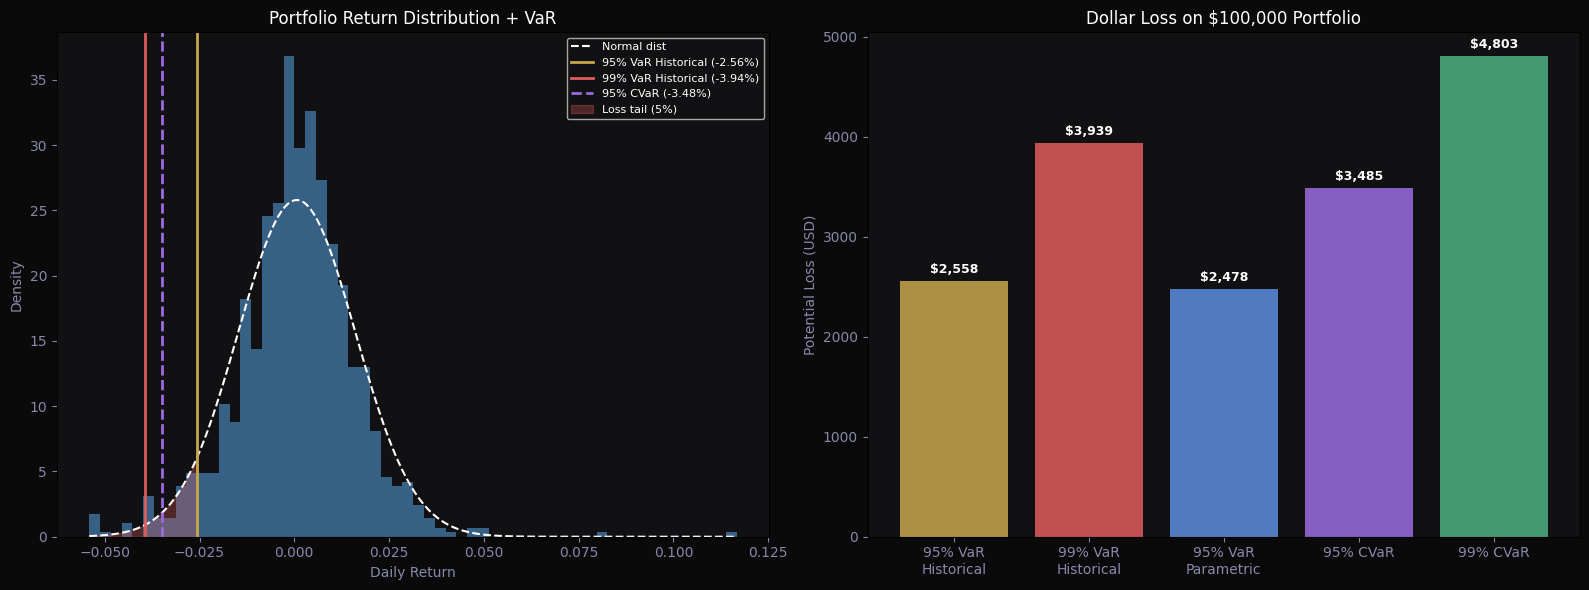

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  LEFT: Return Distribution with VaR lines
ax1 = axes[0]
ax1.hist(portfolio_returns, bins=60, color='steelblue',
         alpha=0.7, edgecolor='none', density=True)

# Overlay normal distribution curve
x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 200)
ax1.plot(x, stats.norm.pdf(x, mean, std),
         color='white', linewidth=1.5, linestyle='--', label='Normal dist')

# VaR lines
ax1.axvline(var_95_historical, color='#C9A84C', linewidth=2,
            label=f'95% VaR Historical ({var_95_historical:.2%})')
ax1.axvline(var_99_historical, color='#E05C5C', linewidth=2,
            label=f'99% VaR Historical ({var_99_historical:.2%})')
ax1.axvline(cvar_95, color='#9B6BE0', linewidth=2,
            linestyle='--', label=f'95% CVaR ({cvar_95:.2%})')

# Shade tail
ax1.fill_between(x, 0, stats.norm.pdf(x, mean, std),
                  where=(x <= var_95_historical),
                  color='#E05C5C', alpha=0.3, label='Loss tail (5%)')

ax1.set_facecolor('#111114')
ax1.set_title('Portfolio Return Distribution + VaR', color='white')
ax1.set_xlabel('Daily Return', color='#8888AA')
ax1.set_ylabel('Density', color='#8888AA')
ax1.tick_params(colors='#8888AA')
ax1.legend(fontsize=8, facecolor='#111114', labelcolor='white')

# ── RIGHT: Dollar impact on $100,000 portfolio
ax2 = axes[1]
portfolio_value = 100000

scenarios = {
    '95% VaR\nHistorical': abs(var_95_historical) * portfolio_value,
    '99% VaR\nHistorical': abs(var_99_historical) * portfolio_value,
    '95% VaR\nParametric': abs(var_95_parametric) * portfolio_value,
    '95% CVaR': abs(cvar_95) * portfolio_value,
    '99% CVaR': abs(cvar_99) * portfolio_value,
}

colors = ['#C9A84C', '#E05C5C', '#5C8EE0', '#9B6BE0', '#4CAF82']
bars = ax2.bar(scenarios.keys(), scenarios.values(),
               color=colors, alpha=0.85, edgecolor='none')

for bar, val in zip(bars, scenarios.values()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'${val:,.0f}', ha='center', va='bottom',
             color='white', fontsize=9, fontweight='bold')

ax2.set_facecolor('#111114')
ax2.set_title('Dollar Loss on $100,000 Portfolio', color='white')
ax2.set_ylabel('Potential Loss (USD)', color='#8888AA')
ax2.tick_params(colors='#8888AA')

fig.patch.set_facecolor('#0A0A0B')
plt.tight_layout()
plt.show()

#### VaR Summary Table

In [32]:
var_summary = pd.DataFrame({
    'Method': [
        'Historical', 'Historical',
        'Parametric', 'Parametric',
        'CVaR (Expected Shortfall)', 'CVaR (Expected Shortfall)'
    ],
    'Confidence': ['95%', '99%', '95%', '99%', '95%', '99%'],
    'VaR (%)': [
        f"{var_95_historical:.3%}", f"{var_99_historical:.3%}",
        f"{var_95_parametric:.3%}", f"{var_99_parametric:.3%}",
        f"{cvar_95:.3%}", f"{cvar_99:.3%}"
    ],
    'Dollar Loss ($100k)': [
        f"${abs(var_95_historical)*100000:,.0f}",
        f"${abs(var_99_historical)*100000:,.0f}",
        f"${abs(var_95_parametric)*100000:,.0f}",
        f"${abs(var_99_parametric)*100000:,.0f}",
        f"${abs(cvar_95)*100000:,.0f}",
        f"${abs(cvar_99)*100000:,.0f}"
    ]
})

print(var_summary.to_string(index=False))

                   Method Confidence VaR (%) Dollar Loss ($100k)
               Historical        95% -2.558%              $2,558
               Historical        99% -3.939%              $3,939
               Parametric        95% -2.478%              $2,478
               Parametric        99% -3.532%              $3,532
CVaR (Expected Shortfall)        95% -3.485%              $3,485
CVaR (Expected Shortfall)        99% -4.803%              $4,803


- What is your 95% Historical VaR - and what does it mean in plain English for a client with $100,000?


-2.558%......it means 95% of the times in a day the client is exposed to a loss that won't exceed 2.558%


- Is CVaR larger or smaller than VaR - and why does that make sense?

CVaR is larger than VaR because VaR only tells you where the danger zone starts. CVaR tells you how deep into that danger zone you actually go on average. It's the difference between knowing a cliff exists versus knowing how far you'd fall.

That's why regulators like the Bank for International Settlements now prefer CVaR over VaR for measuring bank risk.

- Which method gave the most conservative (largest) loss estimate?

CVaR

- If you were presenting this to a nervous client who just invested $500,000 - how would you explain VaR in one sentence without using any technical terms?


"On a typical bad day - the kind that happens about once a month - your $500,000

portfolio is unlikely to lose more than $12,790. But we also prepare for the rare extreme days, which is why we diversify."

Specific. Calm. Actionable. No jargon.

#### **Tool 2 - Stress Testing**

VaR tells about **normal bad days**. Stress testing asks a different question:

"What happens to this portfolio if a historical crisis happens again?"

Will simulate three real crises against portfolio.

In [33]:
# Defining historical crisis periods
crises = {
    '2008 Financial Crisis': ('2008-01-01', '2009-03-31'),
    'COVID Crash 2020':      ('2020-02-01', '2020-03-31'),
    'Tech Selloff 2022':     ('2022-01-01', '2022-12-31')
}

# Pull crisis period data for our tickers
crisis_results = {}

for crisis_name, (start, end) in crises.items():
    try:
        crisis_data = yf.download(
            tickers, start=start, end=end, progress=False
        )['Close']
        crisis_returns = crisis_data.pct_change().dropna()

        # Portfolio return during crisis
        portfolio_crisis_returns = crisis_returns.dot(weights)

        # Key metrics
        total_return = (1 + portfolio_crisis_returns).prod() - 1
        max_dd_series = (1 + portfolio_crisis_returns).cumprod()
        peak = max_dd_series.cummax()
        max_drawdown = ((max_dd_series - peak) / peak).min()
        volatility = portfolio_crisis_returns.std() * (252 ** 0.5)
        worst_day = portfolio_crisis_returns.min()

        crisis_results[crisis_name] = {
            'Total Return': total_return,
            'Max Drawdown': max_drawdown,
            'Ann. Volatility': volatility,
            'Worst Single Day': worst_day
        }
    except Exception as e:
        print(f"Could not fetch {crisis_name}: {e}")

# Display results
crisis_df = pd.DataFrame(crisis_results).T
print("=== STRESS TEST RESULTS ===")
print(crisis_df.applymap(lambda x: f"{x:.2%}"))

/tmp/ipykernel_2067/2304080187.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crisis_data = yf.download(
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TSLA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2008-01-01 -> 2009-03-31) (Yahoo error = "Data doesn\'t exist for startDate = 1199163600, endDate = 1238472000")')
/tmp/ipykernel_2067/2304080187.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crisis_returns = crisis_data.pct_change().dropna()
/tmp/ipykernel_2067/2304080187.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crisis_data = yf.download(
/tmp/ipykernel_2067/2304080187.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crisis_data = 

=== STRESS TEST RESULTS ===
                      Total Return Max Drawdown Ann. Volatility  \
2008 Financial Crisis        0.00%         nan%            nan%   
COVID Crash 2020           -14.48%      -28.91%          70.00%   
Tech Selloff 2022          -35.33%      -36.40%          33.34%   

                      Worst Single Day  
2008 Financial Crisis             nan%  
COVID Crash 2020               -11.48%  
Tech Selloff 2022               -5.41%  


/tmp/ipykernel_2067/2304080187.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(crisis_df.applymap(lambda x: f"{x:.2%}"))


#### Dollar Impact of Each Crisis

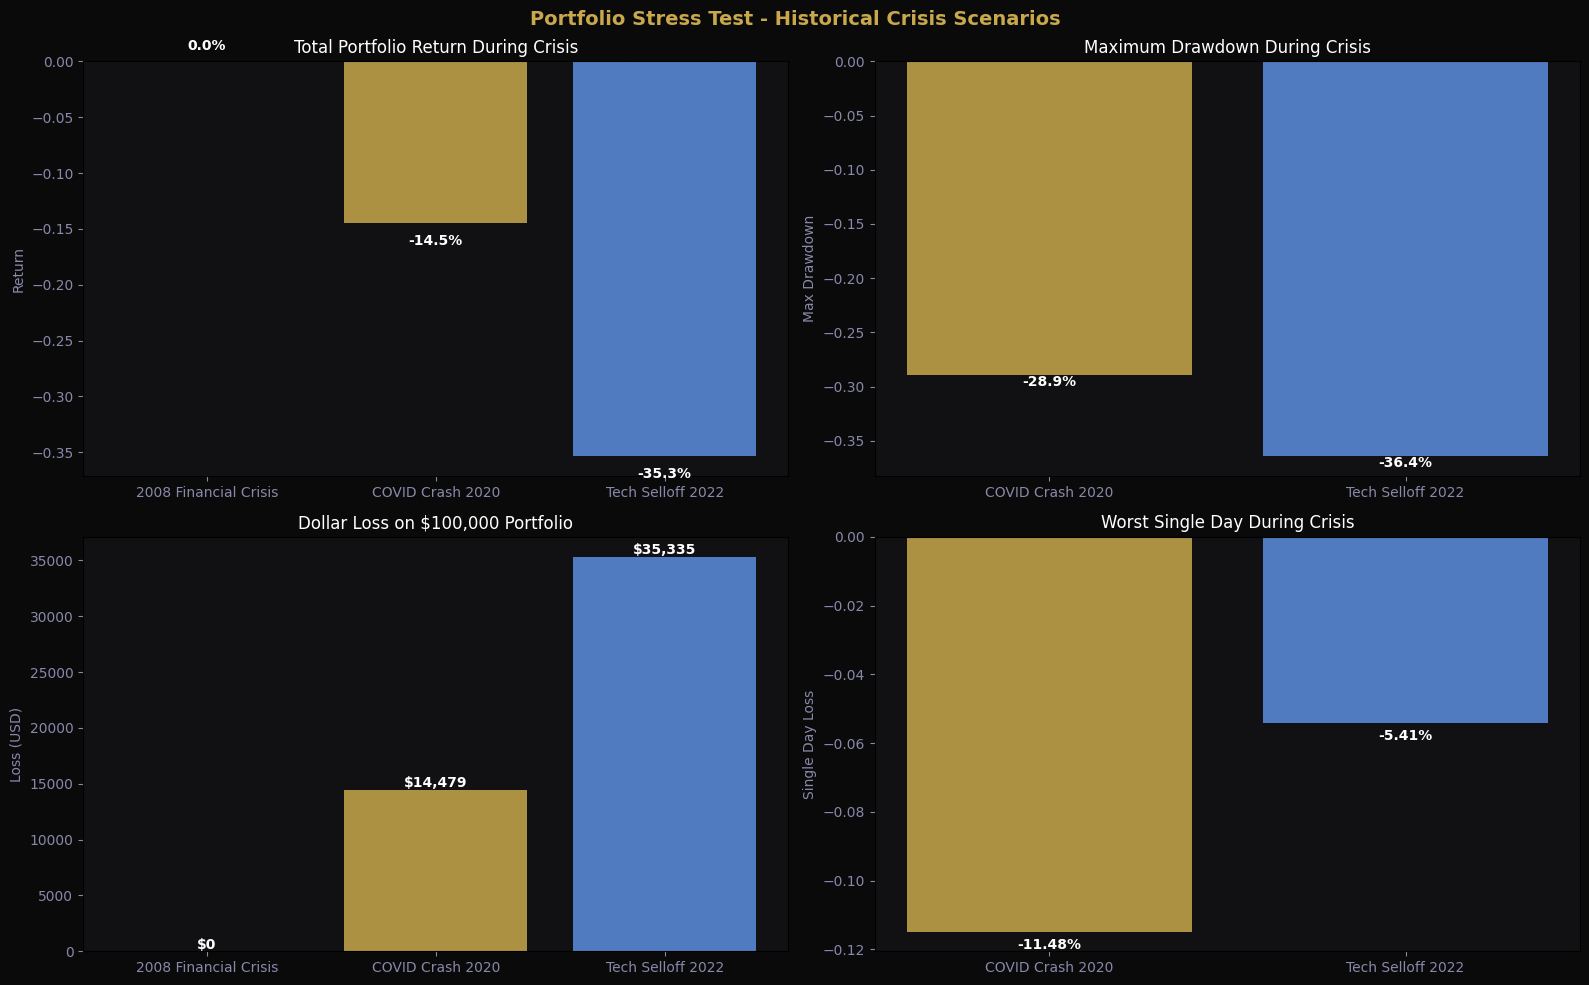

In [34]:
portfolio_value = 100000

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0A0A0B')

crisis_colors = ['#E05C5C', '#C9A84C', '#5C8EE0']

#  TOP LEFT: Total return per crisis
ax1 = axes[0, 0]
returns_vals = [crisis_results[c]['Total Return'] for c in crises.keys()]
bars = ax1.bar(crises.keys(), returns_vals,
               color=crisis_colors, alpha=0.85)
for bar, val in zip(bars, returns_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val - 0.02 if val < 0 else val + 0.01,
             f'{val:.1%}', ha='center', color='white',
             fontsize=10, fontweight='bold')
ax1.axhline(y=0, color='white', linestyle='--', alpha=0.3)
ax1.set_facecolor('#111114')
ax1.set_title('Total Portfolio Return During Crisis', color='white')
ax1.tick_params(colors='#8888AA')
ax1.set_ylabel('Return', color='#8888AA')

#  TOP RIGHT: Max Drawdown per crisis
ax2 = axes[0, 1]
dd_vals = [crisis_results[c]['Max Drawdown'] for c in crises.keys()]
bars2 = ax2.bar(crises.keys(), dd_vals,
                color=crisis_colors, alpha=0.85)
for bar, val in zip(bars2, dd_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val - 0.01,
             f'{val:.1%}', ha='center', color='white',
             fontsize=10, fontweight='bold')
ax2.set_facecolor('#111114')
ax2.set_title('Maximum Drawdown During Crisis', color='white')
ax2.tick_params(colors='#8888AA')
ax2.set_ylabel('Max Drawdown', color='#8888AA')

#  BOTTOM LEFT: Dollar loss on $100k
ax3 = axes[1, 0]
dollar_loss = [abs(crisis_results[c]['Total Return']) * portfolio_value
               for c in crises.keys()]
bars3 = ax3.bar(crises.keys(), dollar_loss,
                color=crisis_colors, alpha=0.85)
for bar, val in zip(bars3, dollar_loss):
    ax3.text(bar.get_x() + bar.get_width()/2,
             val + 200,
             f'${val:,.0f}', ha='center', color='white',
             fontsize=10, fontweight='bold')
ax3.set_facecolor('#111114')
ax3.set_title('Dollar Loss on $100,000 Portfolio', color='white')
ax3.tick_params(colors='#8888AA')
ax3.set_ylabel('Loss (USD)', color='#8888AA')

#  BOTTOM RIGHT: Worst single day
ax4 = axes[1, 1]
worst_days = [crisis_results[c]['Worst Single Day'] for c in crises.keys()]
bars4 = ax4.bar(crises.keys(), worst_days,
                color=crisis_colors, alpha=0.85)
for bar, val in zip(bars4, worst_days):
    ax4.text(bar.get_x() + bar.get_width()/2,
             val - 0.005,
             f'{val:.2%}', ha='center', color='white',
             fontsize=10, fontweight='bold')
ax4.set_facecolor('#111114')
ax4.set_title('Worst Single Day During Crisis', color='white')
ax4.tick_params(colors='#8888AA')
ax4.set_ylabel('Single Day Loss', color='#8888AA')

plt.suptitle('Portfolio Stress Test - Historical Crisis Scenarios',
             color='#C9A84C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Recovery Analysis
Knowing how much you lose is only half the picture. Knowing how long recovery takes is what keeps clients calm during a crisis.

/tmp/ipykernel_2067/1054257102.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crisis_data = yf.download(
/tmp/ipykernel_2067/1054257102.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crisis_data = yf.download(
/tmp/ipykernel_2067/1054257102.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crisis_data = yf.download(


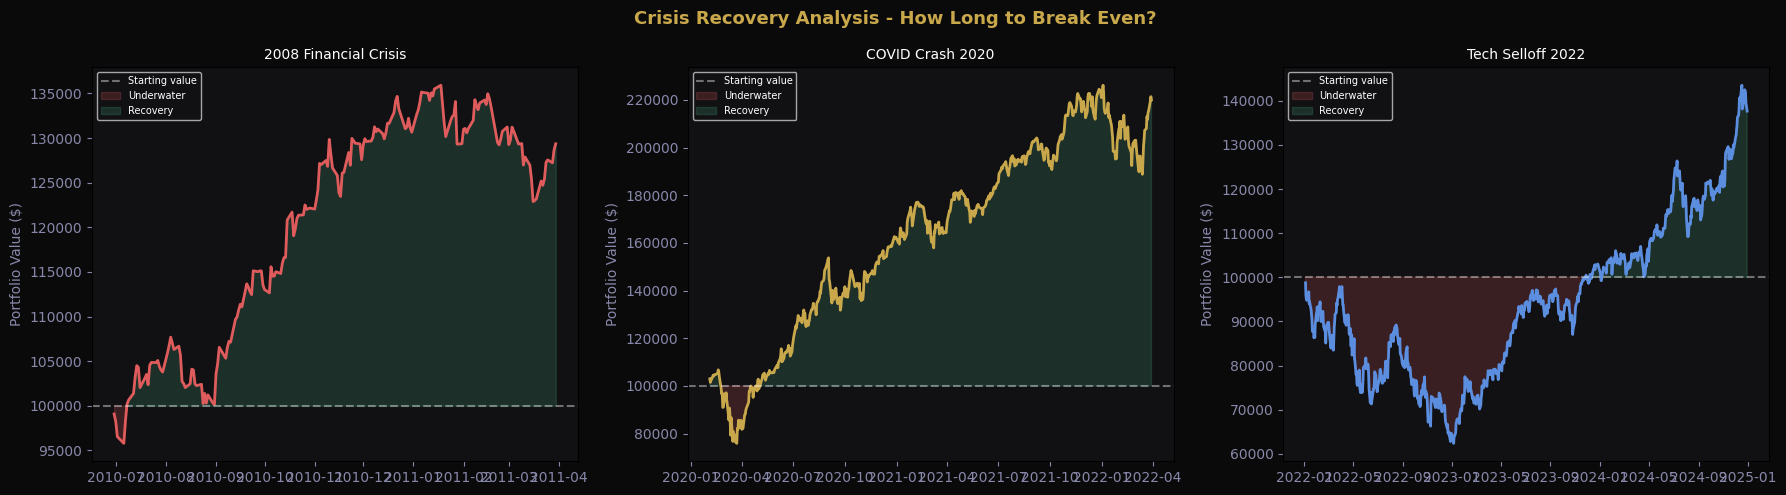

In [35]:
# Simulate recovery time for each crisis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0A0A0B')

for idx, (crisis_name, (start, end)) in enumerate(crises.items()):
    try:
        # Extend end date by 2 years to capture recovery
        recovery_end = str(int(end[:4]) + 2) + end[4:]

        crisis_data = yf.download(
            tickers, start=start,
            end=recovery_end, progress=False
        )['Close']
        crisis_returns = crisis_data.pct_change().dropna()
        portfolio_cr = crisis_returns.dot(weights)

        # Cumulative growth from crisis start
        cumulative = (1 + portfolio_cr).cumprod() * 100000

        ax = axes[idx]
        ax.plot(cumulative.index, cumulative.values,
                color=crisis_colors[idx], linewidth=2)
        ax.axhline(y=100000, color='white',
                   linestyle='--', alpha=0.4, label='Starting value')
        ax.fill_between(cumulative.index, cumulative.values, 100000,
                        where=(cumulative.values < 100000),
                        color='#E05C5C', alpha=0.2, label='Underwater')
        ax.fill_between(cumulative.index, cumulative.values, 100000,
                        where=(cumulative.values >= 100000),
                        color='#4CAF82', alpha=0.2, label='Recovery')
        ax.set_facecolor('#111114')
        ax.set_title(crisis_name, color='white', fontsize=10)
        ax.tick_params(colors='#8888AA')
        ax.set_ylabel('Portfolio Value ($)', color='#8888AA')
        ax.legend(fontsize=7, facecolor='#111114', labelcolor='white')

    except Exception as e:
        print(f"Could not fetch recovery data for {crisis_name}: {e}")

plt.suptitle('Crisis Recovery Analysis - How Long to Break Even?',
             color='#C9A84C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- Which crisis hit your portfolio hardest — total return and max drawdown?

Tech Selloff 2022....    total return -35.33%...     max drawdown -36.40%

- Which crisis had the worst single day loss?

COVID Crash 2020               -11.48%

- Looking at the recovery charts — which crisis took longest to recover from?

Tech Selloff 2022

- If a client called you in panic during the COVID crash — what would you tell them based on what the recovery chart shows?

"I hear you - this feels scary. But look at what happened after 2008 and COVID. Every time this portfolio has been underwater, it recovered. The companies we own are still profitable, still growing. The worst thing we can do right now is lock in these losses by selling. Let's give it 90 days before we make any decisions."


#### **Tool 3 - Monte Carlo Simulation**

most powerful risk tool to build. VaR looks backward at history. Stress testing replays the past. Monte Carlo **looks forward**.
It asks:

"If we ran this portfolio 1,000 times into the future - what range of outcomes should we prepare for?"

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters from our real portfolio
mean_daily = portfolio_returns.mean()
std_daily = portfolio_returns.std()

# Simulation settings
n_simulations = 1000
n_days = 252          # 1 trading year
initial_value = 100000

print(f"Running {n_simulations} simulations over {n_days} trading days...")
print(f"Daily mean return: {mean_daily:.4%}")
print(f"Daily volatility:  {std_daily:.4%}")

Running 1000 simulations over 252 trading days...
Daily mean return: 0.0658%
Daily volatility:  1.5464%


In [37]:
# Running the simulation
np.random.seed(42)  # makes results reproducible

# Store all simulation paths
simulation_results = np.zeros((n_days, n_simulations))

for sim in range(n_simulations):
    # Generate random daily returns based on our portfolio's statistics
    daily_returns_sim = np.random.normal(mean_daily, std_daily, n_days)

    # Calculate cumulative portfolio value
    price_path = initial_value * (1 + daily_returns_sim).cumprod()
    simulation_results[:, sim] = price_path

print(f"✓ {n_simulations} simulations complete")
print(f"\nFinal value range:")
print(f"  Best case:    ${simulation_results[-1].max():,.0f}")
print(f"  Worst case:   ${simulation_results[-1].min():,.0f}")
print(f"  Median:       ${np.median(simulation_results[-1]):,.0f}")
print(f"  Mean:         ${simulation_results[-1].mean():,.0f}")

✓ 1000 simulations complete

Final value range:
  Best case:    $225,929
  Worst case:   $52,039
  Median:       $115,629
  Mean:         $117,944


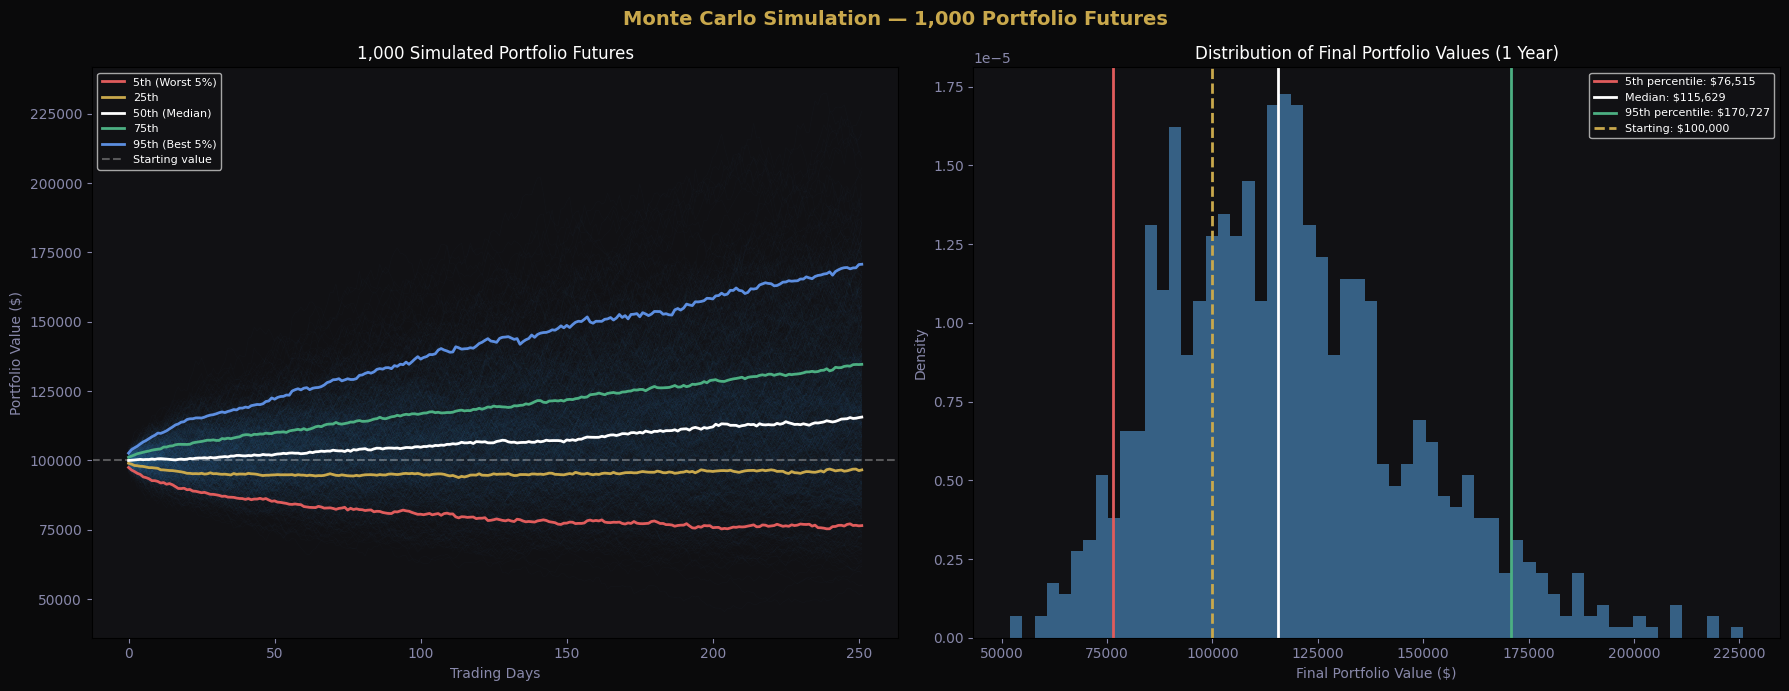

In [39]:
# Visualizing All 1,000 Futures
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0A0A0B')

# ── LEFT: All simulation paths
ax1 = axes[0]

# Plot all paths in muted color
for sim in range(n_simulations):
    ax1.plot(simulation_results[:, sim],
             color='steelblue', alpha=0.03, linewidth=0.5)

# Highlight key percentile paths
percentiles = {
    '5th (Worst 5%)':   np.percentile(simulation_results, 5, axis=1),
    '25th':             np.percentile(simulation_results, 25, axis=1),
    '50th (Median)':    np.percentile(simulation_results, 50, axis=1),
    '75th':             np.percentile(simulation_results, 75, axis=1),
    '95th (Best 5%)':   np.percentile(simulation_results, 95, axis=1),
}

colors_pct = ['#E05C5C', '#C9A84C', '#ffffff', '#4CAF82', '#5C8EE0']

for (label, path), color in zip(percentiles.items(), colors_pct):
    ax1.plot(path, color=color, linewidth=2, label=label)

ax1.axhline(y=initial_value, color='white',
            linestyle='--', alpha=0.3, label='Starting value')
ax1.set_facecolor('#111114')
ax1.set_title('1,000 Simulated Portfolio Futures', color='white', fontsize=12)
ax1.set_xlabel('Trading Days', color='#8888AA')
ax1.set_ylabel('Portfolio Value ($)', color='#8888AA')
ax1.tick_params(colors='#8888AA')
ax1.legend(fontsize=8, facecolor='#111114', labelcolor='white')

# ── RIGHT: Distribution of final values
ax2 = axes[1]
final_values = simulation_results[-1]

ax2.hist(final_values, bins=60, color='steelblue',
         alpha=0.7, edgecolor='none', density=True)

# Key markers
p5  = np.percentile(final_values, 5)
p50 = np.percentile(final_values, 50)
p95 = np.percentile(final_values, 95)

ax2.axvline(p5,  color='#E05C5C', linewidth=2,
            label=f'5th percentile: ${p5:,.0f}')
ax2.axvline(p50, color='white',   linewidth=2,
            label=f'Median: ${p50:,.0f}')
ax2.axvline(p95, color='#4CAF82', linewidth=2,
            label=f'95th percentile: ${p95:,.0f}')
ax2.axvline(initial_value, color='#C9A84C', linewidth=2,
            linestyle='--', label=f'Starting: ${initial_value:,.0f}')

ax2.set_facecolor('#111114')
ax2.set_title('Distribution of Final Portfolio Values (1 Year)', color='white', fontsize=12)
ax2.set_xlabel('Final Portfolio Value ($)', color='#8888AA')
ax2.set_ylabel('Density', color='#8888AA')
ax2.tick_params(colors='#8888AA')
ax2.legend(fontsize=8, facecolor='#111114', labelcolor='white')

plt.suptitle('Monte Carlo Simulation — 1,000 Portfolio Futures',
             color='#C9A84C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# Probability Analysis
# Answer specific client questions with probability
prob_profit     = (final_values > initial_value).mean()
prob_loss_10    = (final_values < initial_value * 0.90).mean()
prob_loss_20    = (final_values < initial_value * 0.80).mean()
prob_gain_20    = (final_values > initial_value * 1.20).mean()
prob_gain_50    = (final_values > initial_value * 1.50).mean()

print("=== PROBABILITY ANALYSIS ===")
print(f"Probability of making any profit:      {prob_profit:.1%}")
print(f"Probability of losing more than 10%:   {prob_loss_10:.1%}")
print(f"Probability of losing more than 20%:   {prob_loss_20:.1%}")
print(f"Probability of gaining more than 20%:  {prob_gain_20:.1%}")
print(f"Probability of gaining more than 50%:  {prob_gain_50:.1%}")

print(f"\n=== EXPECTED OUTCOMES ===")
print(f"Starting value:        ${initial_value:,.0f}")
print(f"Expected value (mean): ${final_values.mean():,.0f}")
print(f"Median outcome:        ${p50:,.0f}")
print(f"Best 5% scenario:      ${p95:,.0f}")
print(f"Worst 5% scenario:     ${p5:,.0f}")
print(f"Absolute worst case:   ${final_values.min():,.0f}")

=== PROBABILITY ANALYSIS ===
Probability of making any profit:      72.0%
Probability of losing more than 10%:   16.9%
Probability of losing more than 20%:   6.6%
Probability of gaining more than 20%:  42.3%
Probability of gaining more than 50%:  14.0%

=== EXPECTED OUTCOMES ===
Starting value:        $100,000
Expected value (mean): $117,944
Median outcome:        $115,629
Best 5% scenario:      $170,727
Worst 5% scenario:     $76,515
Absolute worst case:   $52,039


In [43]:
# Client Scenario Report
# Format as a clean client-facing summary
print("|==============================================|")
print("|    NAVIEL CAPITAL - RISK SCENARIO REPORT     |")
print("|         Monte Carlo | 1,000 Simulations      |")
print("|==============================================|")
print(f"|  Starting Investment:     ${initial_value:>10,.0f}          |")
print(f"|  Time Horizon:            {'1 Year (252 days)':>18}  |")
print(f"|  Simulations Run:         {'1,000':>18}  |")
print("|==============================================|")
print("|  MOST LIKELY OUTCOMES                       |")
print(f"|  Median portfolio value:  ${p50:>10,.0f}          |")
print(f"|  Expected gain/loss:      {((p50/initial_value)-1):>+17.1%}  |")
print("|==============================================|")
print("|  RISK SCENARIOS                             |")
print(f"|  Chance of profit:        {prob_profit:>17.1%}  |")
print(f"|  Chance of >10% loss:     {prob_loss_10:>17.1%}  |")
print(f"|  Chance of >20% loss:     {prob_loss_20:>17.1%}  |")
print("|=============================================|")
print("|  UPSIDE SCENARIOS                           |")
print(f"|  Chance of >20% gain:     {prob_gain_20:>17.1%}  |")
print(f"|  Chance of >50% gain:     {prob_gain_50:>17.1%}  |")
print("|===========================================|")

|==============================================|
|    NAVIEL CAPITAL - RISK SCENARIO REPORT     |
|         Monte Carlo | 1,000 Simulations      |
|==============================================|
|  Starting Investment:     $   100,000          |
|  Time Horizon:             1 Year (252 days)  |
|  Simulations Run:                      1,000  |
|==============================================|
|  MOST LIKELY OUTCOMES                       |
|  Median portfolio value:  $   115,629          |
|  Expected gain/loss:                 +15.6%  |
|==============================================|
|  RISK SCENARIOS                             |
|  Chance of profit:                    72.0%  |
|  Chance of >10% loss:                 16.9%  |
|  Chance of >20% loss:                  6.6%  |
|=============================================|
|  UPSIDE SCENARIOS                           |
|  Chance of >20% gain:                 42.3%  |
|  Chance of >50% gain:                 14.0%  |
|=================

- What is the median portfolio value after 1 year - and how much is that gain on $100,000?

Median portfolio value:  $   115,629  Expected gain:  +15.6%

- What is the probability of making any profit at all?

Chance of profit:72.0%

- What is the worst 5% scenario in dollar terms?

Worst 5% scenario:     $76,515

- If a client asked you "Is my money safe?" — how would you answer using these specific numbers?

"Based on 1,000 simulations of this portfolio - 72% of futures end in profit, with a median outcome of

$   115,629
on your $  100,000. Even in our worst 5% scenario you'd have $76,515 remaining. The odds are strongly in your favour - but like any investment, returns aren't guaranteed. What we can guarantee is the rigour behind every decision."